# This notebook shows you how to generate your own DBOF


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Initial set up
These steps help you build the project on a single machine. If you are using nrp Jupyterhub, it is recommended you use the next block instead.

#### Build the project
- ```pip install .```

#### Install aws cli (optional)
You will want to install this if you want to manually see the data stored in the nrp bucket.

Example for installing on linux :
- ```sudo curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"```
- ```sudo unzip awscliv2.zip```
- ```sudo ./aws/install```

#### Set your aws secret and access keys
This is assuming you will be saving data to s3. If so we need to set your credentials so the script can access your s3 bucket. This will likely be an nrp s3 bucket.

windows:

- ```$env:AWS_ACCESS_KEY_ID="..."```
- ```$env:AWS_SECRET_ACCESS_KEY="..."```

unix:

- ```export AWS_ACCESS_KEY_ID=...```
- ```export AWS_SECRET_ACCESS_KEY=...```

# Dataset generation config (quick reference)

This job is fully controlled by a YAML config file. The config defines **what time range is scanned**, **how often snapshots are taken**, and **how many spatial patches are sampled per snapshot**.

### Temporal sampling
- `data.timestep_hours`
  Total time window (in hours) to scan starting from `start_record`.
  Example: `8760` = one LLC model year (336 days).

- `data.sampling_step`
  Spacing **in hours** between snapshots within the window.
  Example: `2190` with `timestep_hours=8760` → 4 evenly spaced snapshots.

- `data.start_record`
  First valid wind/forcing record (default: `1180`). You probably don't want to change this.

Each snapshot corresponds to a **single instantaneous model timestep** (not an average).

### Spatial sampling
- `sampling.sample_points_per_snapshot`
  Number of cutouts sampled per snapshot.

- `sampling.bias_to_high_gradients`
  Exponential bias favoring high-gradient regions when sampling.

### Patch geometry
- `output.target_km_res`
  Physical patch size in km. Default 150.

- `output.down_sample_res`
  Pixel resolution of the extracted cutouts.
  Must be small enough to safely resolve `target_km_res` on the LLC grid.
  Default 64

### Output / logging
- `output.bucket`, `output.folder`
  S3 location for dataset output.

- `run.run_id`
  Unique identifier for this run (used for logs and output paths).
  If the run_id you use exists on the write location (s3 bucket), your data will be appended to the existing data from previous run(s).

- `run.log_dir`
  Local directory where logs are written.

### Invariants (not configurable)
Grid topology, model cadence (144 timesteps/hour), and dataset offsets are fixed
LLC4320 constants and are enforced in code.

### Examples
See existing configs in configs/ for examples

# A note about logs
The run logs will be stored locally on your machine in the directory you specify.
- ```log_dir/run_id/```
However under the current logic, if you attempt to run the script and the specified log output path already exists, the script will fail to run. This is by design. The reasons are as follows.
- run_id is also used for the zarr dataset path. You likely do not want to send two different runs to the same dataset.
- You will likely not want to override your previous run logs.

If you want to override this logic, simply delete the existing log output path from your local machine. You can also override the run_id with a cli argument ```--run_id```

# Convenience block for running in NRP Jupyterhub

In [2]:
# This is for running this notebook on nrp Jupyterhub. Set True if you are on NRP Jupyterhub
RUNNING_ON_NRP = False

# This builds the project and installs dependencies much faster on jupyterhub than pip install .
# There are much better ways to do this but this notebook is meant to be accessible and easy to use
if (RUNNING_ON_NRP):
    %pip install -e ../. --no-deps

    %pip install xgcm
    %pip install zarr
    %pip install boto3
    %pip install ujson
    %pip install scikit-fmm

    # !sudo curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"
    # !sudo unzip awscliv2.zip
    # !sudo ./aws/install todo do we need aws installed for this notebook?

## Example run 1
- 1 year of data
- 4 time snapshots evenly spaced through the year
- 150 cutouts per timestamp

If you are running this on your laptop or pc expect it to take a while.

In [11]:
import datetime
run_id = f"year_4x150_{datetime.datetime.now(datetime.UTC).strftime('%Y%m%d_%H%M%S')}"
print(f"Your run id is: {run_id}")
print("Make sure and use the same run_d later when accessing your data")

Your run id is: year_4x150_20260129_044851
Make sure and use the same run_d later when accessing your data


In [3]:
# note that --run_id can overwrite the config file
!generate-llc-dataset --config ../configs/example_1year_4_snapshot.yaml --run_id test01

2026-01-28 11:07:44,159 | INFO | Arguments parsed successfully. Logging set up. Running script.
2026-01-28 11:07:45,245 | INFO | Dask Client <Client: 'tcp://127.0.0.1:61213' processes=4 threads=12, memory=31.10 GiB>
2026-01-28 11:07:45,245 | INFO | Processing: [ 180288  495648  811008 1126368] time snapshots
s3://llc/native_grid_dbof_training_data/year_4x150/dataset_creation.zarr
2026-01-28 11:07:45,254 | INFO | Found credentials in shared credentials file: ~/.aws/credentials
2026-01-28 11:07:47,052 | INFO | Zarr dataset_creation created.
2026-01-28 11:07:47,052 | INFO | Fetching grid file
2026-01-28 11:08:27,163 | INFO | Calculating land and face masks
Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.
2026-01-28 11:14:06,850 | INFO | Data loaded for iteration: 180288
2026-01-28 11:14:06,850 | INFO | Calculating ice mask
2026-01-2

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\zarr\core\dtype\npy\bytes.py:386: UnstableSpecificationWarning: The data type (NullTerminatedBytes(length=32)) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)

  0%|          | 0/4 [00:00<?, ?it/s]C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 235.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph with

## Example run 2 - very small
- 2 weeks of data
- 1 snapshot per week
- 10 cutouts per timestamp

If you are running this on your laptop or pc expect it to take a while.

In [4]:
!generate-llc-dataset --config ../configs/test.yaml --run_id test01

2026-01-28 10:04:44,037 | INFO | Arguments parsed successfully. Logging set up. Running script.
2026-01-28 10:04:45,133 | INFO | Dask Client <Client: 'tcp://127.0.0.1:50087' processes=4 threads=12, memory=31.10 GiB>
2026-01-28 10:04:45,133 | INFO | Processing: [180288 204480] time snapshots
s3://llc/native_grid_dbof_training_data/test01/dataset_creation.zarr
2026-01-28 10:04:45,152 | INFO | Found credentials in shared credentials file: ~/.aws/credentials
2026-01-28 10:04:47,007 | INFO | Zarr dataset_creation created.
2026-01-28 10:04:47,007 | INFO | Fetching grid file
2026-01-28 10:04:55,665 | INFO | Calculating land and face masks
Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.
2026-01-28 10:09:31,001 | INFO | Data loaded for iteration: 180288
2026-01-28 10:09:31,001 | INFO | Calculating ice mask
2026-01-28 10:10:02,807 | INFO 

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\zarr\core\dtype\npy\bytes.py:386: UnstableSpecificationWarning: The data type (NullTerminatedBytes(length=32)) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)

  0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 235.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph with

In [3]:
# 4 samples, 1 from each of 4 consecutive weeks

# temporal options ------
timestep_hours = "672"        # how many hours to load total. This example is 4 weeks
sampling_step = "168"         # stride in hours, 1 week
start_record = "1180"         # first valid wind/forcing record begins ~1180, This is also the default start of the script

# spatial options ------
target_km_res = "150"         # km resolution of our patches w and h
down_sample_res = "64"        # pixel resolution of our patches w and h
# NOTE The above are heavily dependent on each other. down_sample_res must be smaller than the smallest possible resolution created by target_km_re on the llc grid. 150 and 64 are safe. Todo it would be nice to create a function to calculate this for the user.
samples_per_snapshot = "25"   # how many patches to take from each snapshot
bias_to_high_gradients = "2"  # see documentation on sampling

# s3 output config ------
# Note: include trailing "/" please
bucket = "llc/"
folder = "native_grid_dbof_training_data/"
run_id = "script_test_00/"   # should be unique for each instance of dbof you wish to create, it is just a folder in s3

s3_endpoint = "https://s3-west.nrp-nautilus.io"



In [4]:
# 4 samples, 1 from each of 4 consecutive weeks

# temporal options ------
#timestep_hours = "8064" # 1 year
#timestep_hours = "336"
timestep_hours = "336"

#sampling_step =  "1344" # 2 montsh "2016" # 3month
sampling_step = "168"

start_record = "1180"         # first valid wind/forcing record begins ~1180, This is also the default start of the script

# spatial options ------
target_km_res = "150"         # km resolution of our patches w and h
down_sample_res = "64"        # pixel resolution of our patches w and h
# NOTE The above are heavily dependent on each other. down_sample_res must be smaller than the smallest possible resolution created by target_km_re on the llc grid. 150 and 64 are safe. Todo it would be nice to create a function to calculate this for the user.
samples_per_snapshot = "150"   # how many patches to take from each snapshot


# s3 output config ------
# Note: include trailing "/" please
bucket = "llc/"
folder = "native_grid_dbof_training_data/"

s3_endpoint = "https://s3-west.nrp-nautilus.io"

bias_to_high_gradients = "1.3"
run_id = "test00"

log_dir = "../test_logs/"



In [5]:
print()
!generate-llc-dataset --sampling_step {sampling_step} --start_record {start_record} --timestep_hours {timestep_hours} --sample_points_per_snapshot {samples_per_snapshot} --bias_to_high_gradients {bias_to_high_gradients} --target_km_res {target_km_res} --down_sample_res {down_sample_res} --bucket {bucket} --folder {folder} --run_id {run_id} --s3_endpoint {s3_endpoint} --log_dir {log_dir}



2026-01-27 18:37:30,107 | INFO | Arguments parsed successfully. Logging set up. Running script.
2026-01-27 18:37:31,428 | INFO | Dask Client <Client: 'tcp://127.0.0.1:53719' processes=4 threads=12, memory=31.10 GiB>
2026-01-27 18:37:31,429 | INFO | Processing: [180288 204480] time snapshots
s3://llc/native_grid_dbof_training_data/test00/dataset_creation.zarr
2026-01-27 18:37:31,442 | INFO | Found credentials in shared credentials file: ~/.aws/credentials
2026-01-27 18:37:32,544 | INFO | Zarr dataset_creation created.
2026-01-27 18:37:32,544 | INFO | Fetching grid file
2026-01-27 18:37:41,659 | INFO | Calculating land and face masks
Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.
2026-01-27 18:42:50,185 | INFO | Data loaded for iteration: 180288
2026-01-27 18:42:50,186 | INFO | Calculating ice mask
2026-01-27 18:43:13,187 | INFO


  0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 235.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\dask\array\reductions.py:292: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\dask\array\reductions.py:292: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
2026-01-27 18:47:26,151 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4a4

In [9]:
print(f"python3 generate_front_training_data.py --sampling_step {sampling_step} --start_record {start_record} --timestep_hours {timestep_hours} --sample_points_per_snapshot {samples_per_snapshot} --bias_to_high_gradients {bias_to_high_gradients} --target_km_res {target_km_res} --down_sample_res {down_sample_res} --bucket {bucket} --folder {folder} --run_id {run_id} --s3_endpoint {s3_endpoint} --num_workers {num_workers}")


NameError: name 'num_workers' is not defined

In [15]:
import fsspec
import pandas as pd

fs_synch = fsspec.filesystem(
    "s3", #
    asynchronous=False,
    client_kwargs={
        "endpoint_url": s3_endpoint,

    },

    # These become botocore.client.Config(...)
    config_kwargs={
        "signature_version": "s3v4",
        "request_checksum_calculation": "when_required",
        "s3": {
            "addressing_style": "path",
            "payload_signing_enabled": False,
            "use_accelerate_endpoint": False,
            "use_dualstack_endpoint": False,
        },
    },
)

fs = fsspec.filesystem(
        "s3",  #
        asynchronous=True,
        client_kwargs={
            "endpoint_url": s3_endpoint,

        },

        # These become botocore.client.Config(...)
        config_kwargs={
            "signature_version": "s3v4",
            "request_checksum_calculation": "when_required",
            "s3": {
                "addressing_style": "path",
                "payload_signing_enabled": False,
                "use_accelerate_endpoint": False,
                "use_dualstack_endpoint": False,
            },
        },
    )

In [13]:
!pip install s3fs

  Using cached botocore-1.40.45-py3-none-any.whl.metadata (5.7 kB)
Using cached botocore-1.40.45-py3-none-any.whl (14.1 MB)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [16]:
files = fs_synch.glob(
    f"llc/native_grid_dbof_training_data/{run_id}metadata/*.parquet"
)

meta_df = pd.read_parquet(files, filesystem=fs_synch)

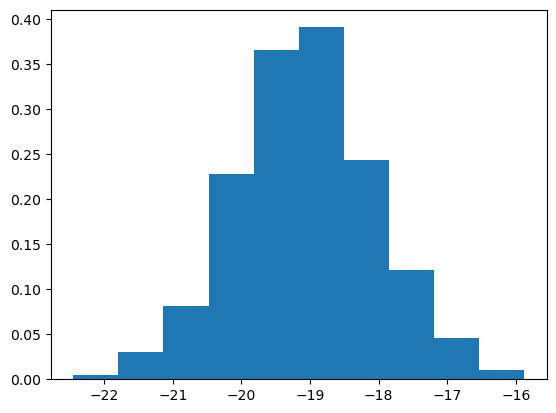

In [16]:
hist, edges = np.histogram(meta_df["log_grad_b_2_center"], bins=10, density=True)

plt.bar(
    edges[:-1],
    hist,
    width=np.diff(edges),
    align="edge"
)

plt.show()

In [27]:

from dbof import dataset_creation as zarr_dataset

In [28]:
reader = zarr_dataset.ZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset_creation.zarr",
    fs=fs
)

img, img_id = reader.get_image(10)

imgs, ids = reader.get_images([0,10,200,250,4,5,6,7,8,9,10])


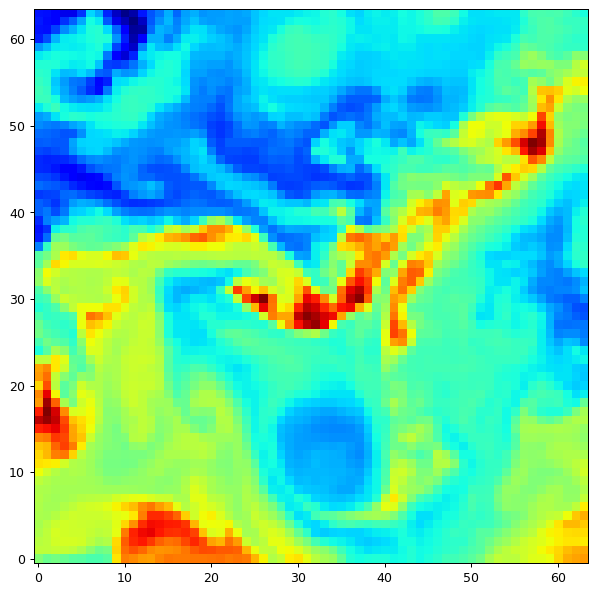

In [33]:


img, img_id = reader.get_image(0)
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(img[2],origin='lower',cmap='jet')

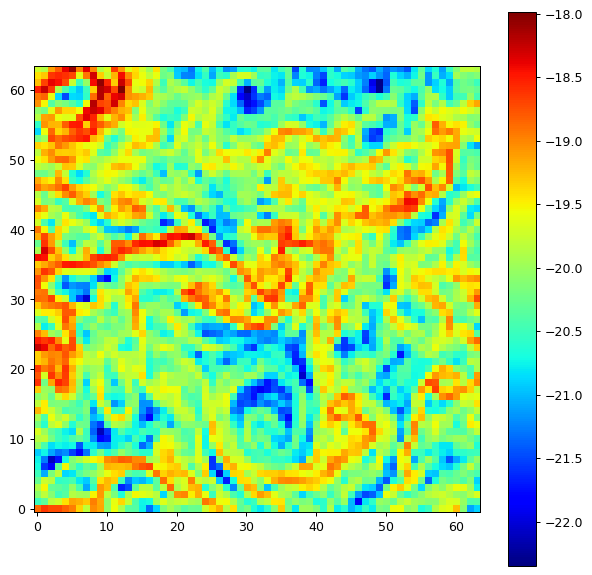

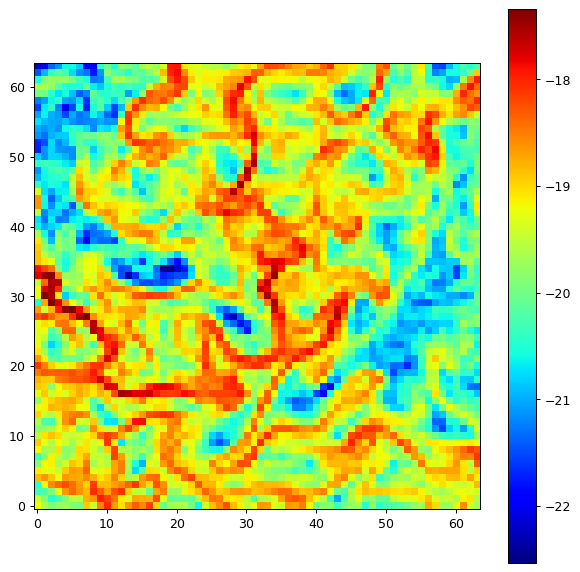

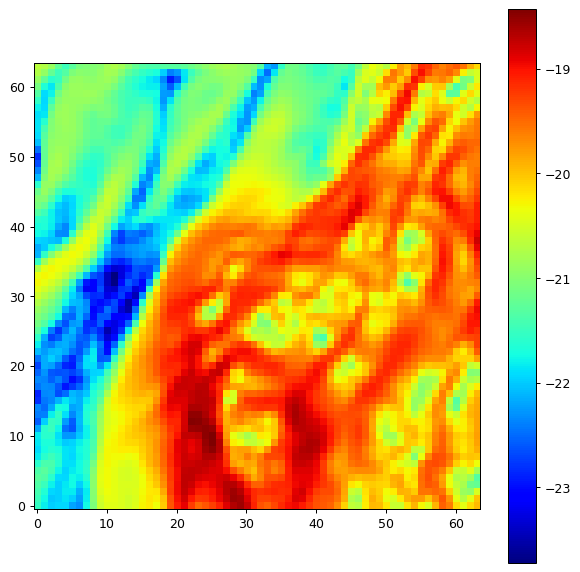

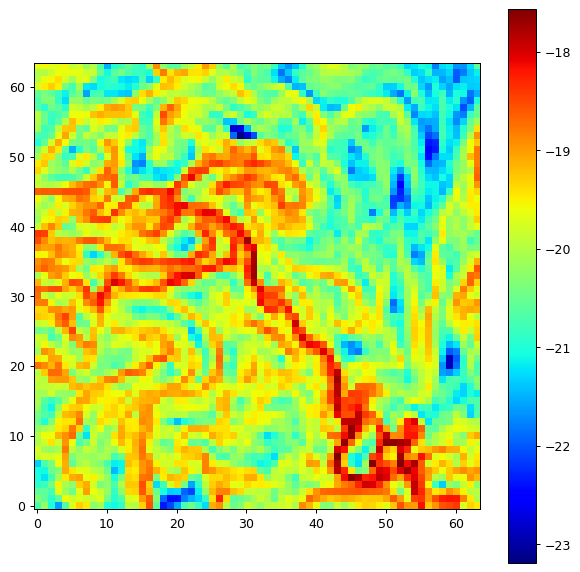

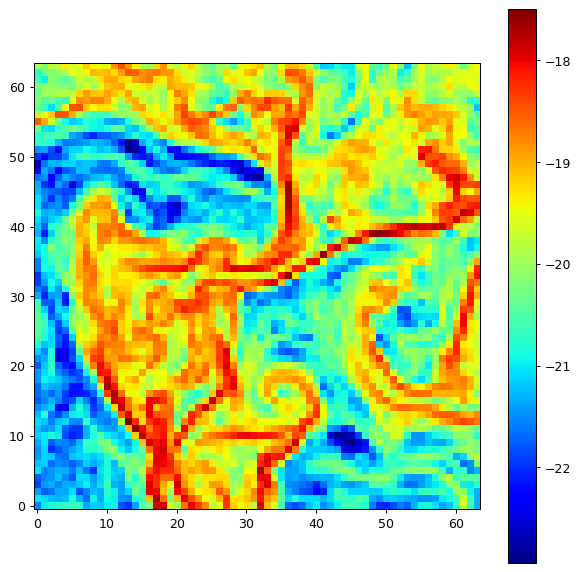

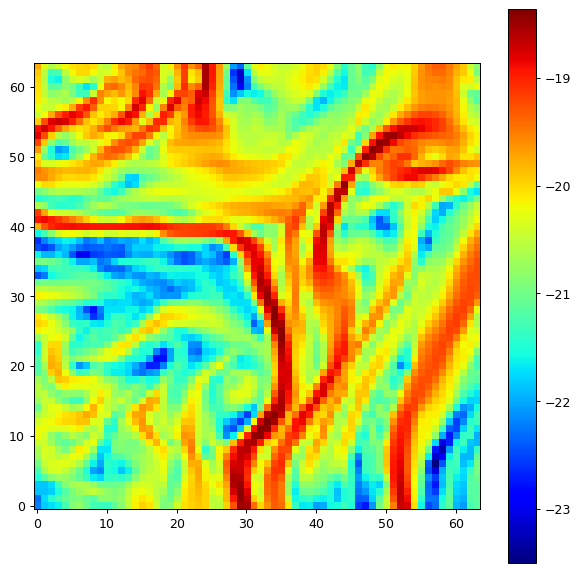

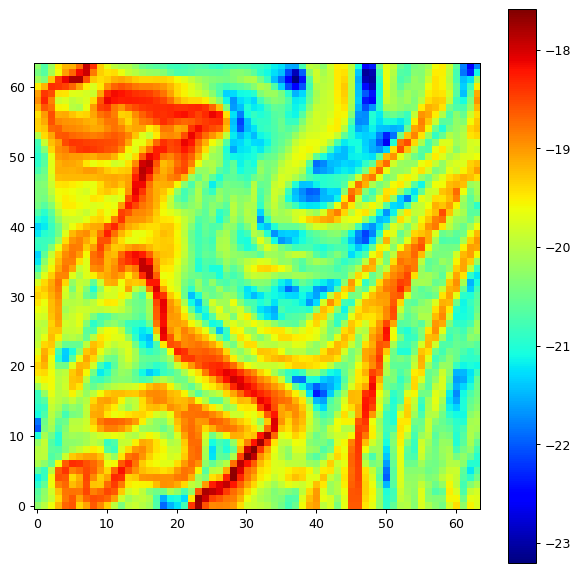

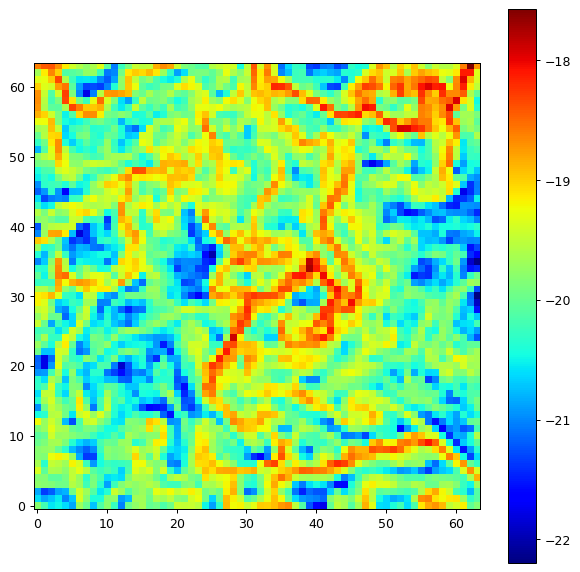

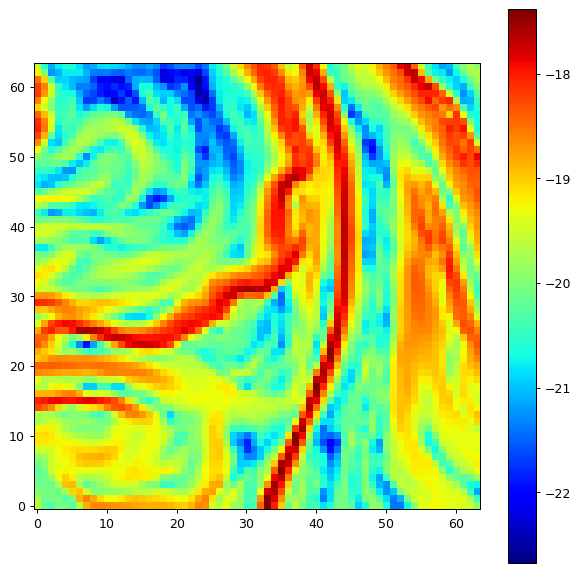

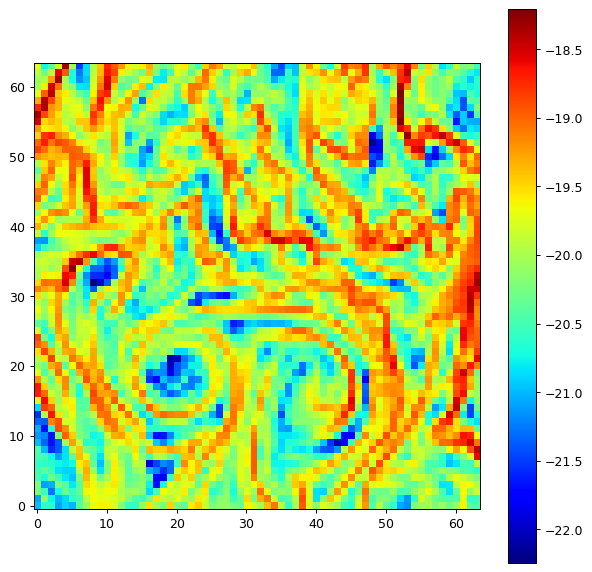

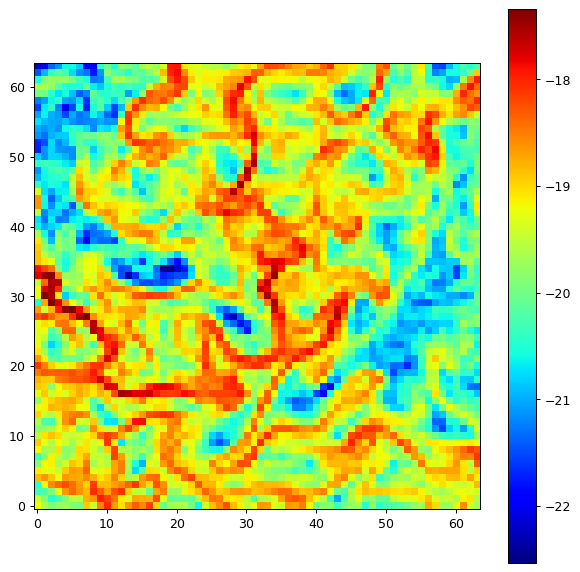

In [34]:
for img in imgs:
    plt.figure(figsize=(8, 8), dpi=90)
    im = plt.imshow(img[6], origin='lower', cmap='jet')
    plt.colorbar(im)
    plt.show()

In [36]:
img[2]

array([[-1.868817 , -1.8688064, -1.8694301, ..., -1.8644925, -1.8637562,
        -1.8645347],
       [-1.8677281, -1.8682638, -1.8690144, ..., -1.8644708, -1.8640054,
        -1.8641361],
       [-1.8670863, -1.868531 , -1.8693634, ..., -1.8637489, -1.8645443,
        -1.864546 ],
       ...,
       [-1.8697902, -1.8698397, -1.8699505, ..., -1.8575621, -1.8571723,
        -1.8567715],
       [-1.8699198, -1.8699011, -1.8699557, ..., -1.857086 , -1.8567749,
        -1.8559121],
       [-1.8698772, -1.8699254, -1.8701295, ..., -1.8559834, -1.8545666,
        -1.8534614]], shape=(64, 64), dtype=float32)

In [ ]:
# aws --endpoint https://s3-west.nrp-nautilus.io s3 ls s3://llc/native_grid_dbof_training_data/script_test_00/ --human-readable
#
# aws --endpoint https://s3-west.nrp-nautilus.io s3 rm s3://llc/native_grid_dbof_training_data/script_test_00/ --recursive --dryrun